In [2]:
import yeager_utils as ut
import numpy as np
import matplotlib.pyplot as plt

(-1.1, 1.1, -1.0998615404412626, 1.0998615404412626)

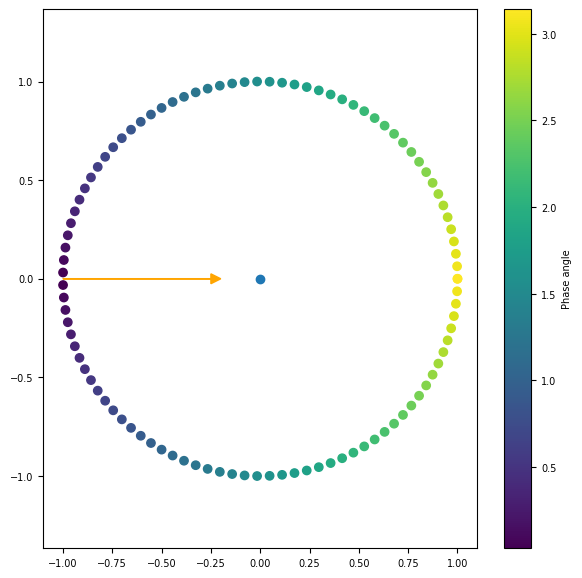

In [33]:
def getAngle(a, b, c):  # a,b,c where b is the vertex
    a = np.atleast_2d(a)
    b = np.atleast_2d(b)
    c = np.atleast_2d(c)
    ba = np.subtract(a, b)
    bc = np.subtract(c, b)
    cosine_angle = np.sum(ba * bc, axis=-1) / (np.linalg.norm(ba, axis=-1) * np.linalg.norm(bc, axis=-1))
    return np.arccos(cosine_angle)


def M_v_lambertian(r, times, radius=1, albedo=0.2):
    sun_Mag = 4.80
    r_sun = get_body('Sun').position(times).T
    r_earth = np.zeros_like(r_sun)
    r_moon = get_body('Moon').position(times).T
    sun_phase = _getAngle(r_sun, r, r_earth)
    earth_phase = _getAngle(r_earth, r, r_earth)
    moon_phase = _getAngle(r_moon, r, r_earth)

    r_earth_sat = np.linalg.norm(r - r_earth, axis=-1)  # Earth is the observer.
    
    f_earth_to_sat = 2 / 3 * albedo_earth * EARTH_RADIUS**2 / (np.pi * (r_earth_sat)**2) * (np.sin(earth_angle) + (np.pi - earth_angle) * np.cos(earth_angle))  # Fraction of sunlight reflected from the Earth to satellite
    
    frac_sun = 2 / 3 * albedo * radius**2 / (np.pi * (r_earth_sat)**2) * (np.sin(sun_phase) + (np.pi - sun_phase) * np.cos(sun_phase))
    frac_earth = 2 / 3 * albedo * radius**2 / (np.pi * (r_earth_sat)**2) * (np.sin(earth_phase) + (np.pi - earth_phase) * np.cos(earth_phase))
    frac_moon = 2 / 3 * albedo * radius**2 / (np.pi * (r_earth_sat)**2) * (np.sin(moon_phase) + (np.pi - moon_phase) * np.cos(moon_phase))
    
    Mv_sun = (2.5 * np.log10((r_sun_sat / (10 * 149_597_870_700))**2) + sun_Mag) - 2.5 * np.log10(frac_sun)
    Mv_earth = (2.5 * np.log10((r_sun_sat / (10 * 149_597_870_700))**2) + sun_Mag) - 2.5 * np.log10(frac_earth)
    Mv_moon = (2.5 * np.log10((r_sun_sat / (10 * 149_597_870_700))**2) + sun_Mag) - 2.5 * np.log10(frac_moon)
    return Mv_sun, Mv_earth, Mv_moon


sun = [-10000, 0, 0]
earth = [0, 0, 0]
angles = np.linspace(0, 2 * np.pi, 100)
for i, angle in enumerate(angles):
    if i == 0:
        phases = getAngle(sun, earth, [np.cos(angle), np.sin(angle), 0])
        continue
    phases = np.vstack((phases, getAngle(sun, earth, [np.cos(angle), np.sin(angle), 0])))


times = ut.get_times(duration=(10, 'days'), freq=(1, 'hr'), t=ut.Time("2025-1-1"))
r, v = ssapy.rv(ssapy.Orbit.fromKeplerianElements(*[2 * ut.RGEO, 0, 0, 0, 0, 0], t=times[0]), times, propagator=ssapy.RK78Propagator(ssapy.AccelKepler(), h=10.0))
flux_sun, flux_earth, flux_moon = M_v_lambertian(r, times)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(1,2,1)
ax.scatter(earth[0], earth[1])
plt.arrow(-1, 0, 0.75, 0, head_width=0.05, head_length=0.05, fc='Orange', ec='Orange', label='Sun')
scatter = ax.scatter(np.cos(angles), np.sin(angles), c=phases)
colorbar = plt.colorbar(scatter, label='Phase angle')
ax.axis('equal')

ax = fig.add_subplot(1,2,2)
ax.scatter(earth[0], earth[1])
plt.arrow(-1, 0, 0.75, 0, head_width=0.05, head_length=0.05, fc='Orange', ec='Orange', label='Sun')
scatter = ax.scatter(np.cos(angles), np.sin(angles), c=phases)
colorbar = plt.colorbar(scatter, label='Phase angle')
ax.axis('equal')

In [ ]:
albedo = 0.2
radius = 1

def phase_angle
r_sun = get_body('Sun').position(times).T
r_earth = np.zeros_like(r_sun)
r_moon = get_body('Moon').position(times).T
sun_phase = phase_angle(r, r_sun)
earth_phase = phase_angle(r, r_sun)
moon_phase = phase_angle(r, r_sun)
r_earth_sat = np.linalg.norm(r - r_earth, axis=-1)  # Earth is the observer.
flux_sun = 2 / 3 * albedo * radius**2 / (np.pi * (r_earth_sat)**2) * (np.sin(sun_phase) + (np.pi - sun_phase) * np.cos(sun_phase))
flux_earth = 2 / 3 * albedo * radius**2 / (np.pi * (r_earth_sat)**2) * (np.sin(earth_phase) + (np.pi - earth_phase) * np.cos(earth_phase))
flux_moon = 2 / 3 * albedo * radius**2 / (np.pi * (r_earth_sat)**2) * (np.sin(moon_phase) + (np.pi - moon_phase) * np.cos(moon_phase))
